# EfficientNet-B0 Experiment 07 — Label Smoothing + WeightedRandomSampler (1:7)

## Objective
Iteration 05 showed a clear overfitting pattern: val loss hit its minimum at epoch 12 (0.671) then diverged to 0.826 by epoch 30, while train loss kept falling to 0.451. The train/val AUC gap grew from ~0.002 early in training to ~0.048 by epoch 30. Two problems are addressed here: (1) logit saturation from hard 0/1 targets, and (2) noisy training curves caused by high batch-to-batch class variance — with batch_size=32 and a 1:8.1 ratio, random shuffling yields only ~3–4 melanoma samples per batch on average, with high variance.

This iteration introduces **label smoothing (ε=0.1)** and a **WeightedRandomSampler enforcing a 1:7 melanoma:nevus ratio** (4 melanoma and 28 nevus per batch). This ratio barely exceeds the natural distribution (~3.5 melanoma/batch), so each melanoma image is repeated only ~1.1× per epoch — effectively no repetition — while stabilising batch-level class variance. `pos_weight` is kept at **7** to match the enforced batch ratio. All other components are held constant.

## Architecture Changes

| Component | Iter 05 (Aug + L1 + Dropout + Metadata) | Iter 07 (Label Smoothing + Sampler 1:7) |
|---|---|---|
| Variant | EfficientNet-B0 | EfficientNet-B0 |
| Unfrozen blocks | Last 6 of `features` | Last 6 of `features` |
| Loss | BCEWithLogitsLoss (pos_weight=8.1) | **LabelSmoothingBCE (ε=0.1, pos_weight=7)** |
| Label smoothing | None | **ε=0.1** |
| Class imbalance handling | pos_weight=8.1, random shuffle | **WeightedRandomSampler (1:7) + pos_weight=7** |
| Weight decay | 1e-3 | 1e-3 |
| L1 lambda | 1e-3 | 1e-3 |
| L2 lambda | 0 | 0 |
| Dropout | 0.5 | 0.5 |
| Patient metadata | age + sex + localization (dim=17) | age + sex + localization (dim=17) |
| LR — backbone | 1e-4 | 1e-4 |
| LR — head | 1e-3 | 1e-3 |
| Scheduler | CosineAnnealingLR | CosineAnnealingLR |
| Epochs | 30 | 30 |

## Hypothesis
Label smoothing prevents logit saturation by making perfect confidence unachievable, keeping val loss from diverging past epoch 12. The 1:7 sampler enforces a stable 4 melanoma per batch (vs the high-variance ~3.5 from random shuffling), reducing loss spikes without requiring significant image repetition. `pos_weight=7` is aligned with the enforced batch ratio rather than the natural 8.1, maintaining appropriate class weighting. Together these changes should produce smoother curves, a smaller train/val AUC gap, and comparable or improved test F2 vs Iter 05 (0.6875).

## Import libraries, set seed, and choose device

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000DatasetWithMetadata
from src.data.transform import get_augmented_train_transforms, get_eval_transforms
from src.models.efficientnet import EfficientNetB0WithMetadata
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
from src.utils import seed_everything, seed_worker

import pandas as pd

g = seed_everything(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
from torch.utils.data import WeightedRandomSampler

METADATA_PATH      = str(ROOT / 'data_new/raw/HAM10000_metadata')
TEST_METADATA_PATH = str(ROOT / 'data_new/raw/ISIC2018_Task3_Test_GroundTruth.csv')

train_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_augmented_train_transforms(image_size=224),
)

# WeightedRandomSampler enforcing 1:7 melanoma:nevus ratio per batch (4 melanoma, 28 nevus).
# Each melanoma image repeats ~1.1x per epoch - effectively no repetition.
train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
TARGET_RATIO = 7  # nevus per melanoma in each batch
class_weights  = {0: TARGET_RATIO / num_nevus, 1: 1.0 / num_melanoma}
sample_weights = train_df['label'].map(class_weights).values
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float64),
    num_samples=len(train_df),
    replacement=True,
    generator=g,
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=4,
    persistent_workers=True,
    worker_init_fn=seed_worker,
)

val_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/val.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

test_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/test'),
    metadata_path=TEST_METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

pos_weight = torch.tensor([float(TARGET_RATIO)], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Melanoma: {num_melanoma} | Nevus: {num_nevus}')
print(f'Expected melanoma/batch: {32 / (TARGET_RATIO + 1):.1f} | Melanoma repeats/epoch: {len(train_df) / (TARGET_RATIO + 1) / num_melanoma:.2f}x')

Positive weight: tensor([7.], device='cuda:0')
Train: 7991 | Val: 2024 | Test: 1511
Melanoma: 877 | Nevus: 7114
Expected melanoma/batch: 4.0 | Melanoma repeats/epoch: 1.14x


## Model Definition

In [3]:
class LabelSmoothingBCE(nn.Module):
    """BCEWithLogitsLoss with label smoothing.

    Soft targets: 0 -> epsilon/2, 1 -> 1 - epsilon/2.
    With epsilon=0.1: negatives become 0.05, positives become 0.95.
    pos_weight is set to match the enforced sampler batch ratio (7).
    """
    def __init__(self, epsilon: float = 0.1, pos_weight=None):
        super().__init__()
        self.epsilon = epsilon
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')

    def forward(self, logits, targets):
        targets_smooth = targets * (1.0 - self.epsilon) + 0.5 * self.epsilon
        return self.bce(logits, targets_smooth)


METADATA_DIM      = 17
DROPOUT           = 0.5
UNFREEZE_N_BLOCKS = 6
LABEL_SMOOTHING   = 0.1

model = EfficientNetB0WithMetadata(
    metadata_dim=METADATA_DIM,
    num_classes=1,
    freeze_backbone=True,
    dropout=DROPOUT,
).to(device)

for block in list(model.features)[-UNFREEZE_N_BLOCKS:]:
    for param in block.parameters():
        param.requires_grad = True

criterion = LabelSmoothingBCE(epsilon=LABEL_SMOOTHING, pos_weight=pos_weight)

unfrozen_params = [p for block in list(model.features)[-UNFREEZE_N_BLOCKS:]
                   for p in block.parameters()]
optimizer = optim.AdamW([
    {'params': unfrozen_params,                  'lr': 1e-4},
    {'params': model.meta_encoder.parameters(),  'lr': 1e-3},
    {'params': model.head.parameters(),          'lr': 1e-3},
], weight_decay=1e-3)

num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 1e-3
L2_LAMBDA = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {DROPOUT} | Label smoothing: {LABEL_SMOOTHING}')

Trainable params: 3,990,347 / 4,009,437
L1 lambda: 0.001 | L2 lambda: 0.0 | Dropout: 0.5 | Label smoothing: 0.1


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA, use_metadata=True,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device, use_metadata=True)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/efficientnet_b0_label_smooth_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

KeyboardInterrupt: 

## Plot Train and Validation Curves

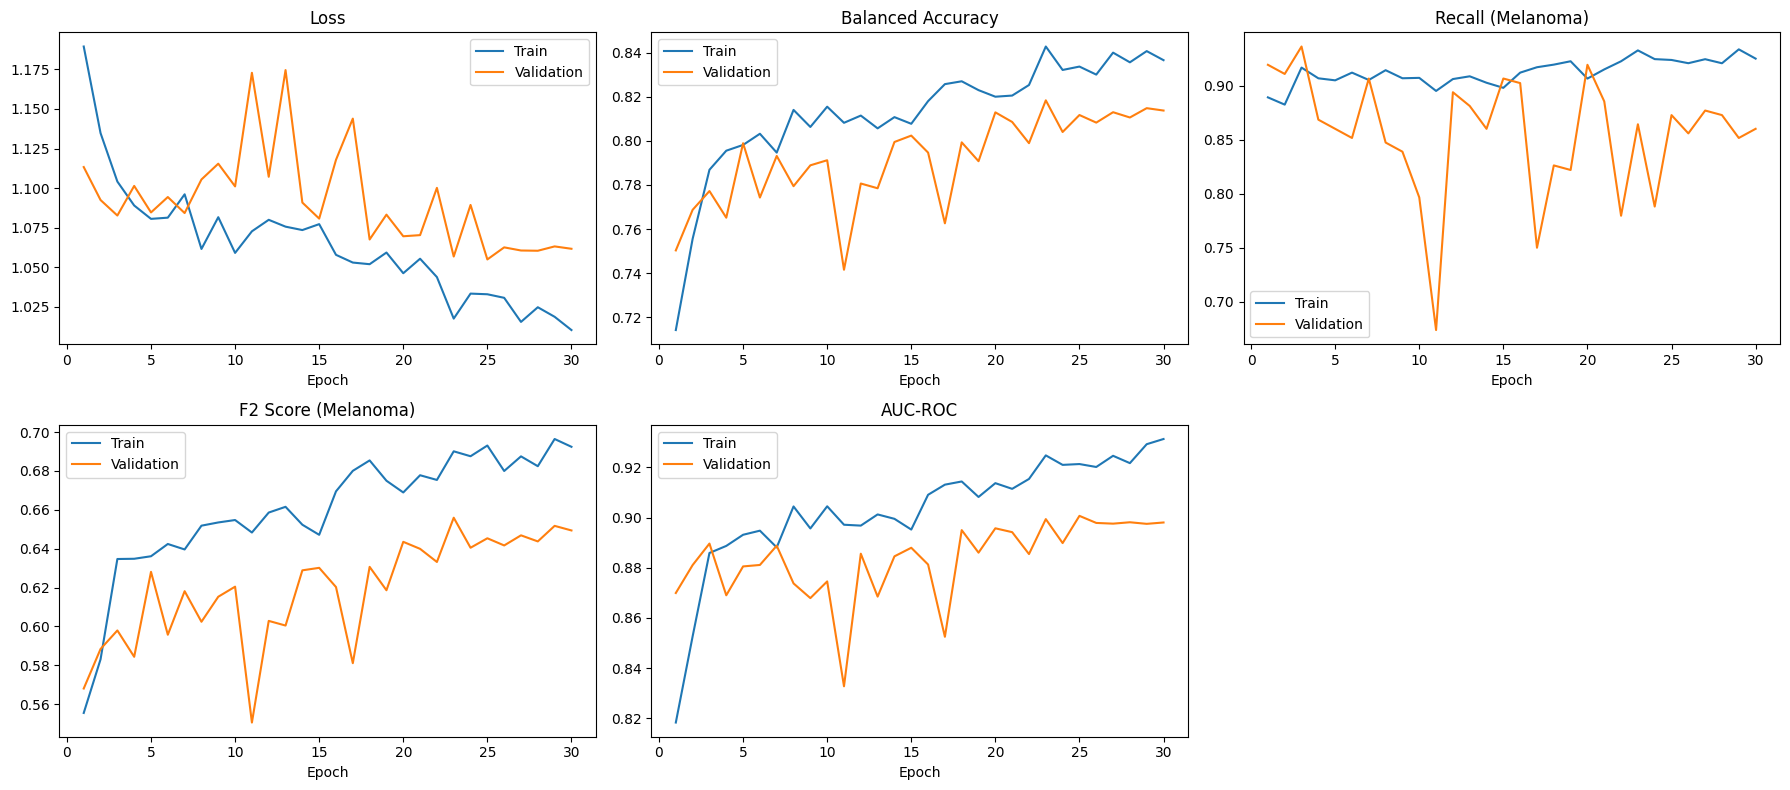

In [ ]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [ ]:
model.load_state_dict(torch.load(str(ROOT / 'models/efficientnet_b0_label_smooth_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device, use_metadata=True)

Best threshold: 0.51 | Val F2: 0.6516


## Test Set Evaluation

Threshold:          0.51
AUC-ROC:            0.9024
Balanced Accuracy:  0.8217
F2 Score:           0.6531

              precision    recall  f1-score   support

Non-Melanoma     0.9808    0.7604    0.8567      1340
    Melanoma     0.3199    0.8830    0.4697       171

    accuracy                         0.7743      1511
   macro avg     0.6503    0.8217    0.6632      1511
weighted avg     0.9060    0.7743    0.8129      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


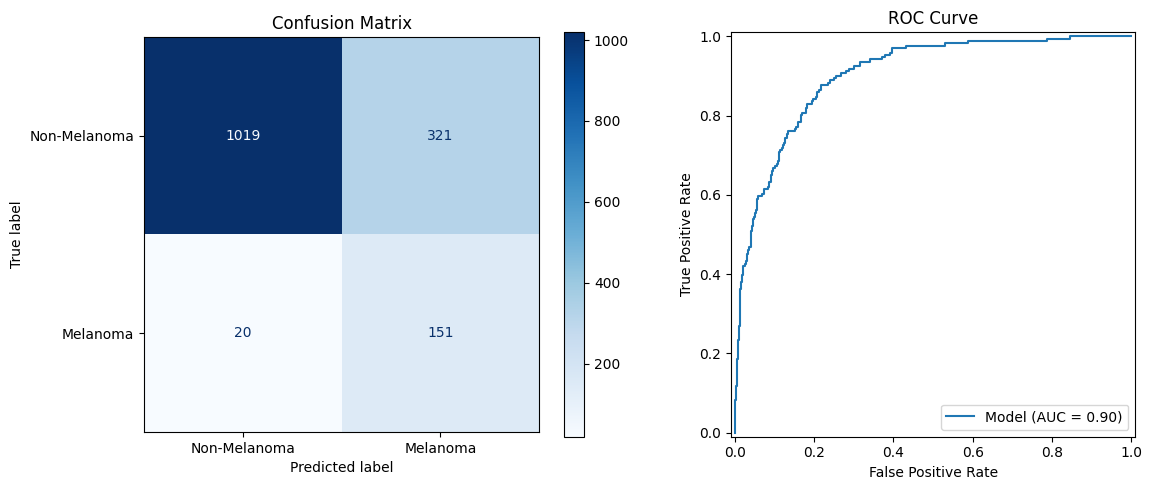

In [ ]:
evaluate_model(model, test_loader, device, threshold=best_threshold, use_metadata=True)